# **Practical Session 1**

#**0. Preamble**

### **0.1. Installing packages and importing modules**

In [2]:
%%capture
! pip install matplotlib
! pip install numpy
! pip install qibo

In [3]:
from qibo    import Circuit, gates, models
from qibo.ui import plot_circuit

import logging
import matplotlib.pyplot as plt
import numpy             as np

# no timestamps
logging.getLogger("qibo").setLevel(logging.ERROR)

###**0.2. Printing and plotting function**

In [4]:
def plot_measurement_results(counts, shots, title="Measurement Results"):
    """
    Prints the measurement counts and probabilities and plots a histogram.

    Parameters
    ----------
    counts : dict
        Dictionary containing the measured states and their counts.
        Example: {'00': 512, '11': 488}
    shots : int
        Total number of shots (measurements).
    title : str, optional
        Title of the histogram.
    """

    # Print measurement results
    print("Measurement counts:\n")
    print("State | Freq  | Probability")
    print("-" * 32)

    for state, count in sorted(counts.items()):
        probability = count / shots
        print(f"{state:>5} | {count:>5} | {probability:.4f}")

    # Plot histogram
    plt.figure(figsize=(6, 4))
    plt.bar(counts.keys(), counts.values())
    plt.title(title)
    plt.xlabel("Measured State")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()

#**1. The Superposition and the Hadamard Gate**

In the first practice, the Hadamard gate is applied to a pure state, the basis element $|000\rangle$, in order to create an uniform superposition state. Then, the measurement is performed to obtain the statistics about the collapse in each state.

- Hadamard gate:

$$H =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}$$

- Evolving the state in the circuit:

 $$H^{⨂3} |000\rangle = \frac{1}{\sqrt{8}} (|000\rangle + |001\rangle + |010\rangle + |100\rangle + |011\rangle + |101\rangle + |110\rangle + |111\rangle)$$
  
🟢 **TO DO:** Build a 3-qubits uniform superposition state by means of Hadamard Gate.

### **1.1. Visualizing the superposition**

### **EXERCISE 1:**

1. Prepare a uniform superposition state of three qubits.

2. Print the final state.

3. Measure (collapse) the final state 1024 times and evaluate the probabilities.

(<Axes: >, <Figure size 60x60 with 1 Axes>)

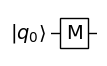

In [5]:
# step 1
# 1-qubit circuit

q0 = Circuit(1)
q0.add(gates.M(0))

# plotting the 1-quibit circuit
plot_circuit(q0)

In [6]:
# printing the state-vector

final = q0()

print("Final state: |psi> = ", final)

[Qibo 0.3.4|INFO|2026-09-12 13:02:52]: Using numpy backend on /CPU:0
INFO:qibo.config:Using numpy backend on /CPU:0


Final state: |psi> =  (1+0j)|0>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |  1024 | 1.0000


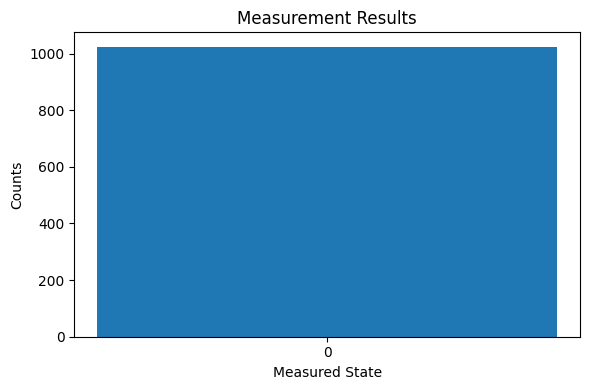

In [7]:
# Measuring the final state for statistics

# number of measurments (shots)
shots = 1024

# measuring the final state
result = q0(nshots = shots)

# counting the results
counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

(<Axes: >, <Figure size 120x60 with 1 Axes>)

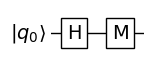

In [8]:
# step 2
# initiating the circuit
circuit0 = Circuit(1)

# applying the Hadamard gate to 1 qubit
circuit0.add(gates.H(0))

# applying the measurement gate to 1 qubit
circuit0.add(gates.M(0))

# plotting the circuit
plot_circuit(circuit0)

In [9]:
# printing the state vector uniform superposition
final_state0 = circuit0()
print("Final state: |psi> = ", final_state0)

Final state: |psi> =  (0.70711+0j)|0> + (0.70711+0j)|1>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |   493 | 0.4814
    1 |   531 | 0.5186


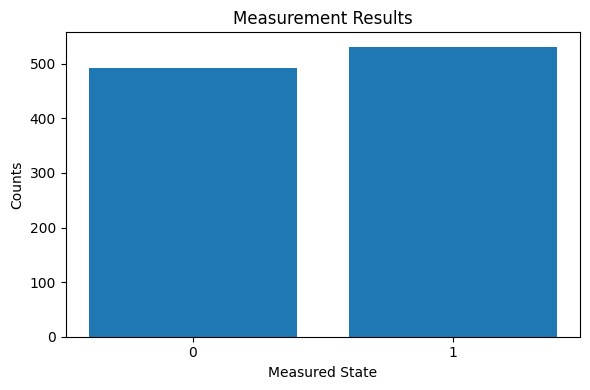

In [10]:
# now we want to measure 0 and 1

# number of shots
shots = 1024

# measuring the final state
result0 = circuit0(nshots = shots)

# counting the results
counts0 = result0.frequencies()

# plotting
plot_measurement_results(counts0, shots)

(<Axes: >, <Figure size 120x180 with 1 Axes>)

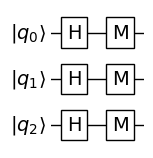

In [11]:
# step 3

# 3-qubit circuit
n = 3
circuit1 = Circuit(n)

# applying the Hadamard gate to all qubits
for q in range(n): circuit1.add(gates.H(q))

# applying the Measurement gate to all qubits
for q in range(n): circuit1.add(gates.M(q))

# circuit plot
plot_circuit(circuit1)

In [12]:
# printing the state vector uniform superposition
final_state1 = circuit1()
print("Final state: |psi> = ", final_state1)

Final state: |psi> =  (0.35355+0j)|000> + (0.35355+0j)|001> + (0.35355+0j)|010> + (0.35355+0j)|011> + (0.35355+0j)|100> + (0.35355+0j)|101> + (0.35355+0j)|110> + (0.35355+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   120 | 0.1172
  001 |   129 | 0.1260
  010 |   148 | 0.1445
  011 |   126 | 0.1230
  100 |   132 | 0.1289
  101 |   125 | 0.1221
  110 |   113 | 0.1104
  111 |   131 | 0.1279


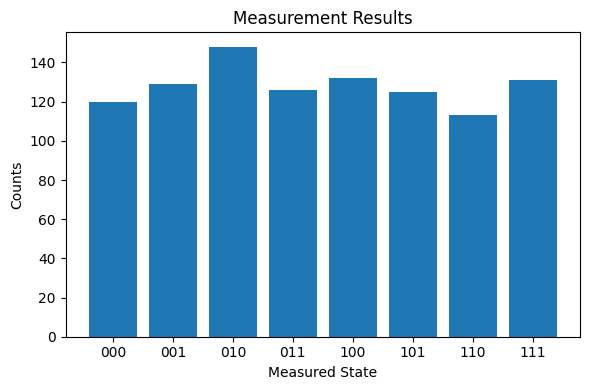

In [13]:
# number of shots
shots = 1024

# measuring the final state
result1 = circuit1(nshots = shots)

# counting the results
counts1 = result1.frequencies()

# plotting
plot_measurement_results(counts1, shots)

#**2. The Relative Phase and the S and T Gates**

The S and T gates are single-qubit phase gates that modify the relative phase of a quantum state. These are crucial for quantum interference and constructing more complex gates, like the controlled-phase gate. In this step, these gates are applied and the statistics of the measurements is evaluated.

- Rotation gate $R_{z}(\theta)$:
$$R_Z(\theta) =
\begin{pmatrix}
1 & 0 \\
0 & e^{i \theta}
\end{pmatrix}$$

- $S$ gate:

$$S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix} = R_Z(\pi / 2)$$

- $T$ gate:

$$T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i \pi/4}
\end{pmatrix} = R_Z(\pi / 4)$$



🟢 **TO DO:** Dephase the basis-states by means of S and T Gates.

### **2.1 Setting an imaginary phase by applying S Gate**

(<Axes: >, <Figure size 180x60 with 1 Axes>)

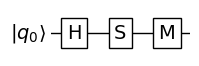

In [14]:
# circuit 2: S gate
circuit2 = Circuit(1)
circuit2.add(gates.H(0))
circuit2.add(gates.S(0))
circuit2.add(gates.M(0))

# circuit plot
plot_circuit(circuit2)

In [15]:
# printing the final vector
final_state2  = circuit2()
print("Final state: |psi> = ", final_state2)

Final state: |psi> =  (0.70711+0j)|0> + 0.70711j|1>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |   473 | 0.4619
    1 |   551 | 0.5381


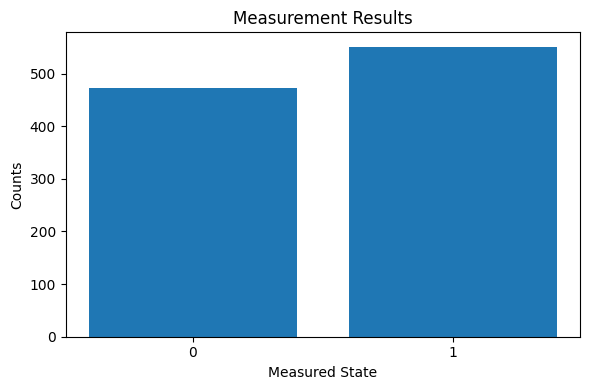

In [16]:
# number of shots
shots = 1024

# measuring the final state
result2 = circuit2(nshots = shots)

# counting the results
counts2 = result2.frequencies()

# plotting
plot_measurement_results(counts2, shots)

### **2.2 Dephasing the basis-state components**

(<Axes: >, <Figure size 240x60 with 1 Axes>)

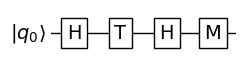

In [17]:
# circuit 3: T gate
circuit3 = Circuit(1)
circuit3.add(gates.H(0))
circuit3.add(gates.T(0))
circuit3.add(gates.H(0))
circuit3.add(gates.M(0))

# circuit plot
plot_circuit(circuit3)

In [18]:
# printing the final vector
final_state3  = circuit3()
print("Final state: |psi> = ", final_state3)

Final state: |psi> =  (0.85355+0.35355j)|0> + (0.14645-0.35355j)|1>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |   864 | 0.8438
    1 |   160 | 0.1562


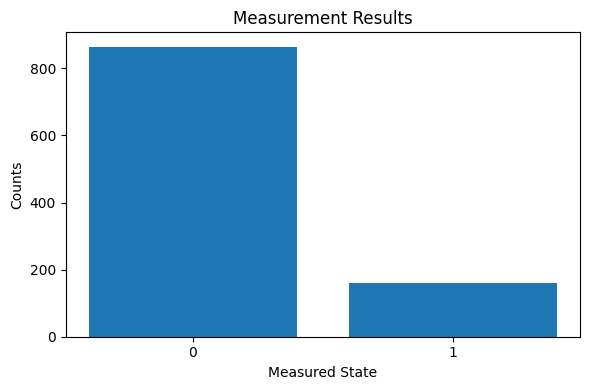

In [19]:
# number of shots
shots = 1024

# measuring the final state
result3 = circuit3(nshots = shots)

# counting the results
counts3 = result3.frequencies()

# plotting
plot_measurement_results(counts3, shots)

#**3. The Entanglement and the CNOT Gate**

To creat an entangled state, the CNOT (controlled-NOT), a two-qubits gate, is applied to the qubits. The CNOT gate flips a state of a target qubit if and only if the control qubit is in state $|1\rangle$, otherwise the target remains unchanged. This gate is responsible for link both qubits.

- Controlled-NOT gate:

$$\text{CNOT} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}$$

- Evolving the state in the circuit:

$H |000\rangle = \frac{1}{\sqrt{2}} (|000\rangle + |100\rangle) = |ψ_1\rangle$

$CNOT^{1,2} |ψ_1\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |110\rangle) = |ψ_2\rangle$

$CNOT^{1,3} |ψ_2\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle) = |ψ_3\rangle = |GHZ\rangle$

🟢 **TO DO:** Build the $|GHZ⟩$ state

### **3.1 The $|{\Phi^{+}}\rangle$ Bell State**

(<Axes: >, <Figure size 180x120 with 1 Axes>)

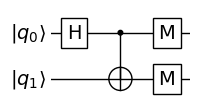

In [20]:
# phi^+ state
# number of qubits
n=2

phi_plus = Circuit(n)

# creating a superposition state
phi_plus.add(gates.H(0))

# entangling both qubits
phi_plus.add(gates.CNOT(0,1))

# applying measurement
phi_plus.add(gates.M(0))
phi_plus.add(gates.M(1))

# plotting the circuit
plot_circuit(phi_plus)

In [21]:
# printing the final vector
final_state = phi_plus()

print("Final state |Psi^+> = ", final_state)

Final state |Psi^+> =  (0.70711+0j)|00> + (0.70711+0j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   532 | 0.5195
   11 |   492 | 0.4805


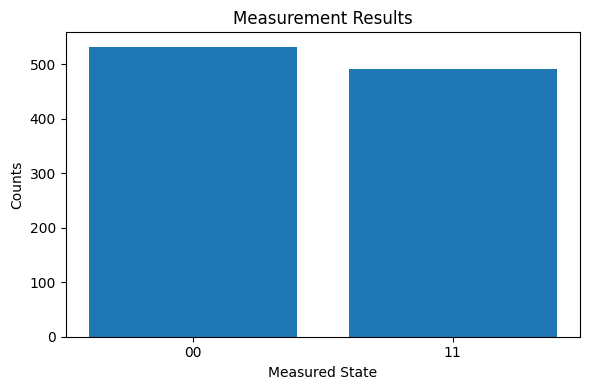

In [22]:
# number of shots
shots = 1024

# measuring the final state
result_phi = phi_plus(nshots = shots)

# counting the results
counts_phi = result_phi.frequencies()

# plotting
plot_measurement_results(counts_phi, shots)

### **EXERCISE 2:**

Build the others Bell States:

a) $|{\Phi^{-}}\rangle$:  use Z Gate to flip the sign

b) $|{\Psi^{+}}\rangle$:  use X Gate to flip the state

c) $|{\Psi^{-}}\rangle$:  use X and Z Gates to flip the state and sign

(<Axes: >, <Figure size 240x120 with 1 Axes>)

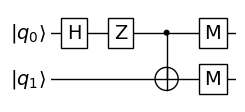

In [23]:
# item a)

# phi^- state
# number of qubits
n=2

phi_min = Circuit(n)

# creating a superposition state
phi_min.add(gates.H(0))

# applying Z gate
phi_min.add(gates.Z(0))

# entangling both qubits
phi_min.add(gates.CNOT(0,1))

# applying measurement
phi_min.add(gates.M(0))
phi_min.add(gates.M(1))

# plotting the circuit
plot_circuit(phi_min)

In [24]:
# printing the final vector
final_state = phi_min()

print("Final state |Psi^-> = ", final_state)

Final state |Psi^-> =  (0.70711+0j)|00> + (-0.70711+0j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   510 | 0.4980
   11 |   514 | 0.5020


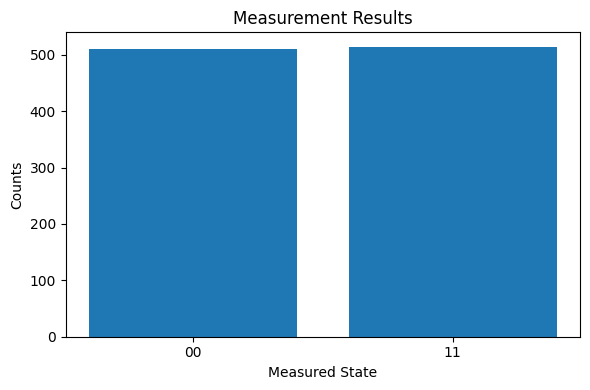

In [25]:
# number of shots
shots = 1024

# measuring the final state
result_phi = phi_min(nshots = shots)

# counting the results
counts_phi = result_phi.frequencies()

# plotting
plot_measurement_results(counts_phi, shots)

Final state |Psi^+> =  (0.70711+0j)|01> + (0.70711+0j)|10>


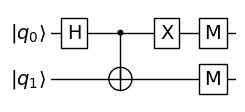

In [26]:
# item b)

# Psi^+ state
# number of qubits
n=2

psi_plus = Circuit(n)

# creating a superposition state
psi_plus.add(gates.H(0))

# entangling both qubits
psi_plus.add(gates.CNOT(0,1))

# applying X gate
psi_plus.add(gates.X(0))

# applying measurement
psi_plus.add(gates.M(0))
psi_plus.add(gates.M(1))

# plotting the circuit
plot_circuit(psi_plus)

# printing the final vector
final_state = psi_plus()

print("Final state |Psi^+> = ", final_state)

In [27]:
# printing the final vector
final_state = psi_plus()

print("Final state |Psi^+> = ", final_state)

Final state |Psi^+> =  (0.70711+0j)|01> + (0.70711+0j)|10>


Measurement counts:

State | Freq  | Probability
--------------------------------
   01 |   500 | 0.4883
   10 |   524 | 0.5117


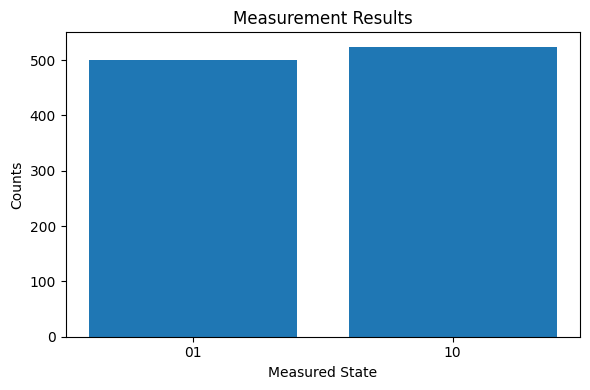

In [28]:
# number of shots
shots = 1024

# measuring the final state
result_psi = psi_plus(nshots = shots)

# counting the results
counts_phi = result_psi.frequencies()

# plotting
plot_measurement_results(counts_phi, shots)

(<Axes: >, <Figure size 300x120 with 1 Axes>)

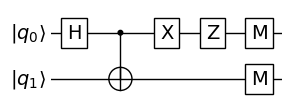

In [29]:
# item c)

# Psi^+ state
# number of qubits
n=2

psi_min = Circuit(n)

# creating a superposition state
psi_min.add(gates.H(0))

# entangling both qubits
psi_min.add(gates.CNOT(0,1))

# applying X gate
psi_min.add(gates.X(0))

# applying Z gate
psi_min.add(gates.Z(0))

# applying measurement
psi_min.add(gates.M(0))
psi_min.add(gates.M(1))

# plotting the circuit
plot_circuit(psi_min)

In [30]:
# printing the final vector
final_state = psi_min()

print("Final state |Psi^-> = ", final_state)

Final state |Psi^-> =  (0.70711+0j)|01> + (-0.70711+0j)|10>


Measurement counts:

State | Freq  | Probability
--------------------------------
   01 |   520 | 0.5078
   10 |   504 | 0.4922


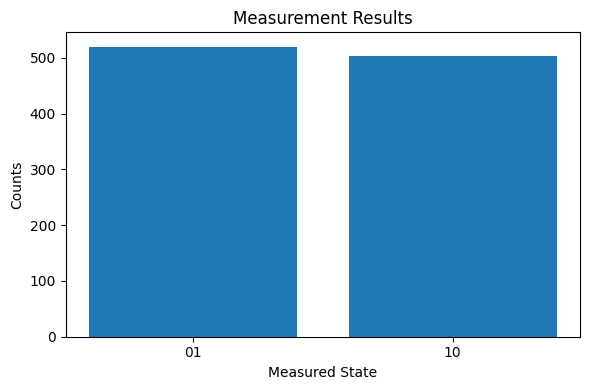

In [31]:
# number of shots
shots = 1024

# measuring the final state
result_psi = psi_min(nshots = shots)

# counting the results
counts_phi = result_psi.frequencies()

# plotting
plot_measurement_results(counts_phi, shots)

### **3.2 The $|GHZ⟩$ State**

(<Axes: >, <Figure size 240x180 with 1 Axes>)

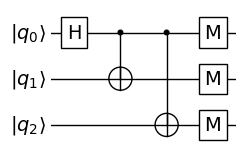

In [32]:
# GHZ state
# number of qubits
n=3

ghz = Circuit(n)

# creating a superposition state
ghz.add(gates.H(0))


# entangling qubits 0 and 1
ghz.add(gates.CNOT(0,1))

# entangling qubits 0 and 2
ghz.add(gates.CNOT(0,2))

# applying measurement
for q in range(n): ghz.add(gates.M(q))

# plotting the circuit
plot_circuit(ghz)

In [33]:
# printing the final vector
final_ghz = ghz()

print("Final state |GHZ> = ", final_ghz)

Final state |GHZ> =  (0.70711+0j)|000> + (0.70711+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   533 | 0.5205
  111 |   491 | 0.4795


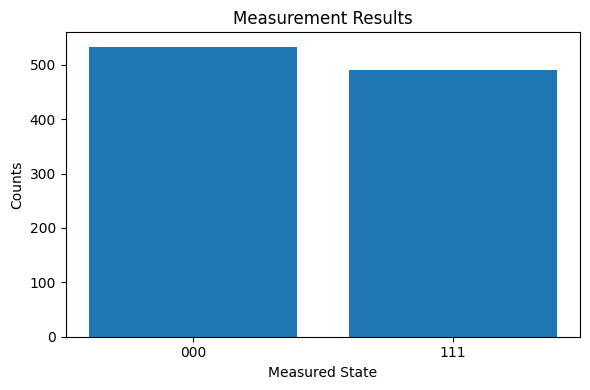

In [34]:
# shots
shots = 1024

result = ghz(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

### **EXERCISE 3:**

1. Build a 3-qubit circuit using Hadamard and CNOT gates.
2. Run the circuit 1024 times.
3. Evaluate the final states and the probabilities.
4. Modify the circuit, run again, and evaluate the new final state.

(<Axes: >, <Figure size 360x180 with 1 Axes>)

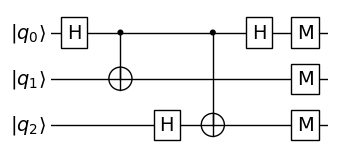

In [51]:
# number of qubits
n=3

qubit3 = Circuit(n)

# creating a superposition state
qubit3.add(gates.H(0))

# entangling qubits
qubit3.add(gates.CNOT(0,1))

qubit3.add(gates.H(2))


qubit3.add(gates.CNOT(0,2))

qubit3.add(gates.H(0))
#qubit3.add(gates.H(1))

# applying measurement
for q in range(n): qubit3.add(gates.M(q))

# plotting the circuit
plot_circuit(qubit3)

In [52]:
# printing the final vector
final_qubit3 = qubit3()

print("Final state |GHZ> = ", final_qubit3)

Final state |GHZ> =  (0.35355+0j)|000> + (0.35355+0j)|001> + (0.35355+0j)|010> + (0.35355+0j)|011> + (0.35355+0j)|100> + (0.35355+0j)|101> + (-0.35355+0j)|110> + (-0.35355+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   132 | 0.1289
  001 |   126 | 0.1230
  010 |   119 | 0.1162
  011 |   128 | 0.1250
  100 |   134 | 0.1309
  101 |   139 | 0.1357
  110 |   135 | 0.1318
  111 |   111 | 0.1084


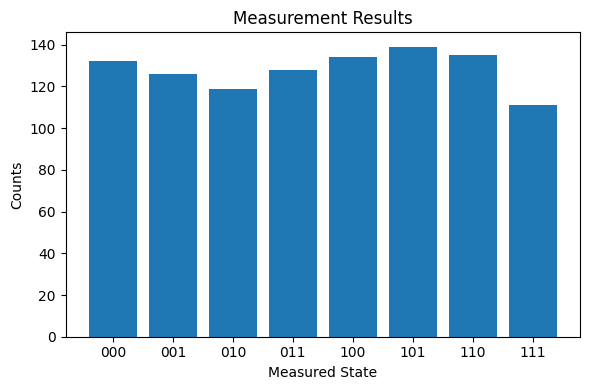

In [53]:
# shots
shots = 1024

result = qubit3(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

#**4. The Controlled Rotation Gates**

Controlled rotation gates are two-qubit controlled operations in which a single-qubit rotation is applied to the target qubit only when the control qubit is in the state $|1\rangle$. If the control qubit is in the state $|0\rangle$, the target qubit remains unchanged.

In general, a controlled rotation gate can be written as


\begin{equation}
CR_{\alpha}(\theta)
=
|0\rangle\langle0|\otimes I
+
|1\rangle\langle1|\otimes R_{\alpha}(\theta),
\qquad \alpha=x,y,z.
\end{equation}


The most commonly used controlled rotation gates are:

- Controlled-$R_{x}$ gate

\begin{equation}
CR_x(\theta)=
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right)\\
0 & 0 & -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
\end{equation}

- Controlled-$R_{y}$ gate

\begin{equation}
CR_y(\theta)=
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right)\\
0 & 0 & \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
\end{equation}

🟢 **TO DO:** Evaluate the final state over different rotations on controlled gates

### **EXERCISE 4:**

1. Build a 2-qubits quantum circuit using Hadamard.
2. Apply the Controlled Rotation Y ($CR_y(\theta)$) or X ($CR_x(\theta)$) gates.
3. Calculate and evaluate the final state for different values of $\theta$ ($\theta = 30, 60, 90, 120, 150$).
4. Plot the histogram and compare the results for the different circuits.

In [38]:
qubit4 = Circuit(2)
theta = [30, 60, 90, 120, 150]

# creating a superposition state
qubit4.add(gates.H(0))
qubit4.add(gates.H(1))

#### **a) CRY($\theta = 30$)**

(<Axes: >, <Figure size 180x120 with 1 Axes>)

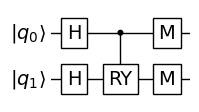

In [39]:
q = qubit4.copy()
i = 0

# apply controlled rotation Y
q.add(gates.CRY(0,1,theta[i]))
q.add(gates.M(0))
q.add(gates.M(1))


plot_circuit(q)

Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   284 | 0.2773
   01 |   227 | 0.2217
   10 |   509 | 0.4971
   11 |     4 | 0.0039


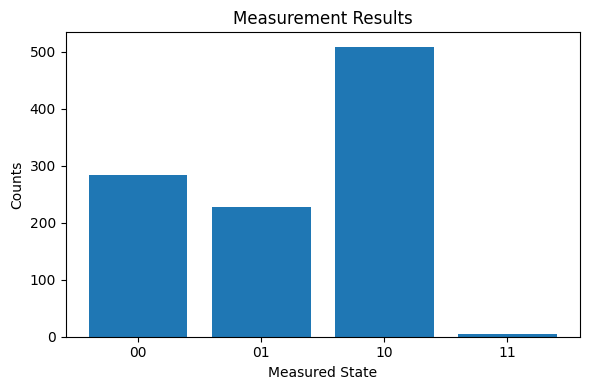

In [40]:
shots = 1024

# Add measurement gates to the circuit q

result = q(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

#### **b) CRX($\theta = 60$)**

(<Axes: >, <Figure size 180x120 with 1 Axes>)

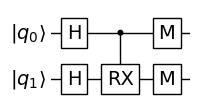

In [41]:
q = qubit4.copy()
i = 1

# apply controlled rotation X
q.add(gates.CRX(0,1,theta[i]))
q.add(gates.M(0))
q.add(gates.M(1))

plot_circuit(q)

Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   224 | 0.2188
   01 |   274 | 0.2676
   10 |   276 | 0.2695
   11 |   250 | 0.2441


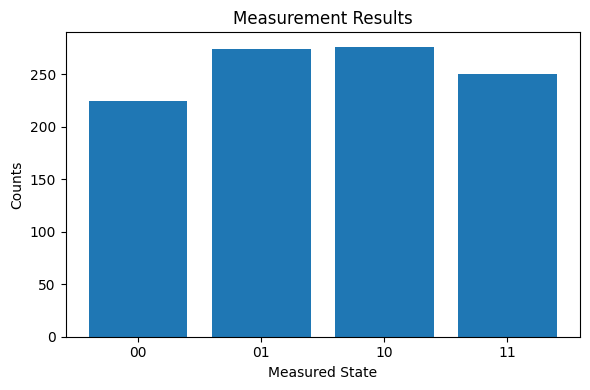

In [42]:
shots = 1024

# Add measurement gates to the circuit q

result = q(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

#### **c) CRY($\theta = 90$) and CRX($\theta = 90$)**

(<Axes: >, <Figure size 240x120 with 1 Axes>)

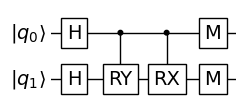

In [43]:
q = qubit4.copy()
i = 2


# apply controlled rotation Y
q.add(gates.CRY(0,1,theta[i]))

# apply controlled rotation X
q.add(gates.CRX(0,1,theta[i]))

q.add(gates.M(0))
q.add(gates.M(1))

plot_circuit(q)

Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   253 | 0.2471
   01 |   256 | 0.2500
   10 |   359 | 0.3506
   11 |   156 | 0.1523


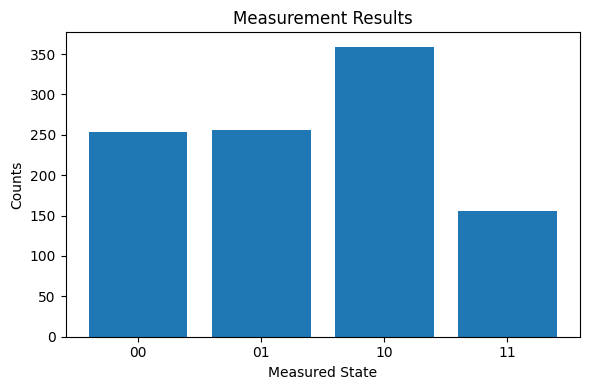

In [44]:
shots = 1024

# Add measurement gates to the circuit q

result = q(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

#### **d) CRX($\theta = 120$) and CRY($\theta = 120$)**

(<Axes: >, <Figure size 240x120 with 1 Axes>)

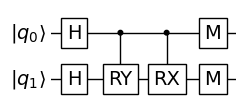

In [45]:
# apply controlled rotation X
q = qubit4.copy()
i = 3


# apply controlled rotation Y
q.add(gates.CRY(0,1,theta[i]))

# apply controlled rotation X
q.add(gates.CRX(0,1,theta[i]))

q.add(gates.M(0))
q.add(gates.M(1))

plot_circuit(q)

Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   244 | 0.2383
   01 |   280 | 0.2734
   10 |   129 | 0.1260
   11 |   371 | 0.3623


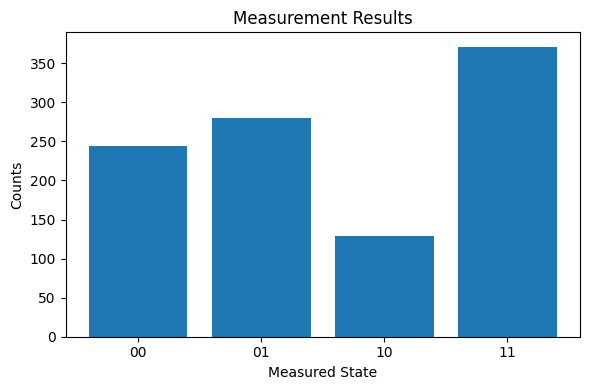

In [46]:
shots = 1024

# Add measurement gates to the circuit q

result = q(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)

#### **e) CRX($\theta = 150$) and CRY($\theta = 150$) and CRX($\theta = 150$)**

(<Axes: >, <Figure size 240x120 with 1 Axes>)

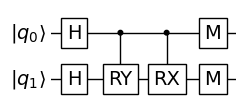

In [47]:
# apply controlled rotation X
q = qubit4.copy()
i = 4


# apply controlled rotation Y
q.add(gates.CRY(0,1,theta[i]))

# apply controlled rotation X
q.add(gates.CRX(0,1,theta[i]))

q.add(gates.M(0))
q.add(gates.M(1))

plot_circuit(q)

Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   246 | 0.2402
   01 |   247 | 0.2412
   10 |   400 | 0.3906
   11 |   131 | 0.1279


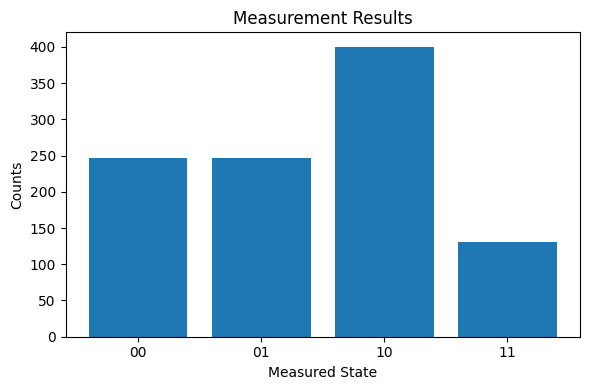

In [48]:
shots = 1024

# Add measurement gates to the circuit q

result = q(nshots = shots)

counts = result.frequencies()

# plotting the measurement results
plot_measurement_results(counts, shots)